In [1]:
import os
import json
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve, confusion_matrix

# Set plot styling
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.size'] = 10

# Safe target models directory resolution
if os.path.basename(os.getcwd()) == 'notebooks':
    models_dir = os.path.abspath(os.path.join(os.getcwd(), '..', 'models'))
else:
    models_dir = os.path.abspath(os.path.join(os.getcwd(), 'models'))

os.makedirs(models_dir, exist_ok=True)
print(f"Target Models Directory: {models_dir}")


Target Models Directory: d:\PROJECTS\HealthSence_AI\backend\models


In [2]:
# Generate Liver Disease Dataset with Probabilistic Risk Modeling
np.random.seed(303)
num_records = 2500

ages = np.random.randint(18, 85, size=num_records)
genders = np.random.choice(['male', 'female', 'other'], size=num_records, p=[0.52, 0.44, 0.04])
heights = np.random.normal(171, 10, size=num_records)
weights = np.clip(heights * 0.47 + np.random.normal(0, 12, size=num_records), 40, 150)
bmis = weights / ((heights / 100) ** 2)

smokers = np.random.choice(['yes', 'no'], size=num_records, p=[0.22, 0.78])
alcohol_use = np.random.choice(['low', 'moderate', 'high'], size=num_records, p=[0.50, 0.35, 0.15])
activities = np.random.choice(['sedentary', 'moderate', 'active'], size=num_records, p=[0.36, 0.44, 0.20])
sleep_hours = np.clip(np.random.normal(6.9, 1.2, size=num_records), 4, 10)

systolic = np.clip(110 + (bmis - 22) * 1.1 + (ages - 30) * 0.3 + np.random.normal(0, 8, size=num_records), 85, 195).astype(int)
diastolic = np.clip(70 + (bmis - 22) * 0.75 + (ages - 30) * 0.15 + np.random.normal(0, 6, size=num_records), 55, 118).astype(int)
cholesterol = np.clip(175 + (bmis - 22) * 2.5 + (ages - 30) * 0.85 + np.random.normal(0, 16, size=num_records), 100, 400).astype(int)
glucose = np.clip(86 + (bmis - 22) * 1.3 + np.random.normal(0, 11, size=num_records), 55, 260).astype(int)
insulin = np.clip(5 + (glucose - 85) * 0.13 + np.random.normal(0, 3, size=num_records), 2, 50).astype(int)
heart_rate = np.clip(67 + (bmis - 22) * 0.45 + np.random.normal(0, 8, size=num_records), 45, 130).astype(int)

# Target risk logit calculation for Liver Disease
alcohol_high = (alcohol_use == 'high').astype(float) * 1.2
alcohol_mod = (alcohol_use == 'moderate').astype(float) * 0.4

logit_liver = (
    -4.8
    + alcohol_high
    + alcohol_mod
    + 0.065 * (bmis - 25)
    + 0.018 * (cholesterol - 180)
    + 0.015 * (glucose - 90)
    + 0.020 * (ages - 35)
    + np.random.normal(0, 0.4, size=num_records)
)
prob_liver = 1 / (1 + np.exp(-logit_liver))
y_liver = (np.random.rand(num_records) < prob_liver).astype(int)

df_liver_disease = pd.DataFrame({
    'age': ages, 'gender': genders, 'height': heights, 'weight': weights, 'bmi': bmis,
    'smoking': smokers, 'alcohol': alcohol_use, 'physical_activity': activities,
    'sleep_duration': sleep_hours, 'bp_systolic': systolic, 'bp_diastolic': diastolic,
    'cholesterol': cholesterol, 'glucose': glucose, 'insulin': insulin, 'heart_rate': heart_rate,
    'liver_disease': y_liver
})

csv_path = os.path.join(models_dir, "liver_disease_dataset.csv")
df_liver_disease.to_csv(csv_path, index=False)
print(f"Saved Liver Disease Dataset to: {csv_path} ({len(df_liver_disease)} records, {y_liver.sum()} positive cases [{y_liver.mean()*100:.1f}%])")


Saved Liver Disease Dataset to: d:\PROJECTS\HealthSence_AI\backend\models\liver_disease_dataset.csv (2500 records, 140 positive cases [5.6%])


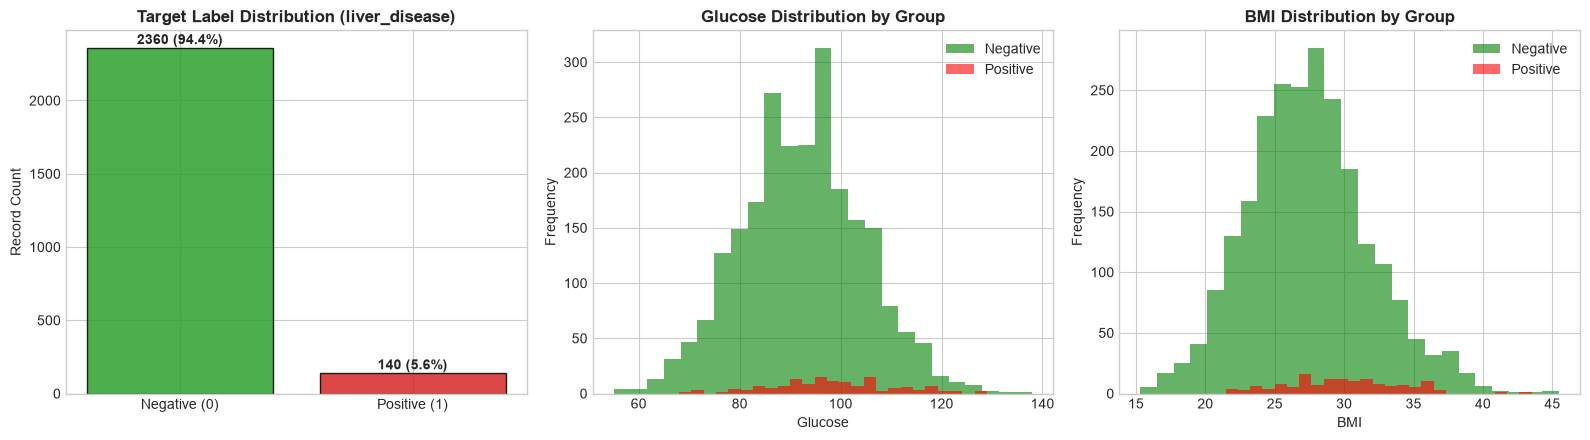

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

df_data = df_liver_disease
target_col = 'liver_disease'
counts = df_data[target_col].value_counts()
colors = ['#2ca02c', '#d62728']
axes[0].bar(['Negative (0)', 'Positive (1)'], [counts.get(0, 0), counts.get(1, 0)], color=colors, alpha=0.85, edgecolor='black')
axes[0].set_title('Target Label Distribution (liver_disease)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Record Count')
for i, val in enumerate([counts.get(0, 0), counts.get(1, 0)]):
    axes[0].text(i, val + 25, f"{val} ({val/len(df_data)*100:.1f}%)", ha='center', fontweight='bold')

feat1 = 'glucose' if 'glucose' in df_data else 'bp_systolic'
axes[1].hist(df_data[df_data[target_col]==0][feat1], bins=25, alpha=0.6, label='Negative', color='green')
axes[1].hist(df_data[df_data[target_col]==1][feat1], bins=25, alpha=0.6, label='Positive', color='red')
axes[1].set_title(f'{feat1.capitalize()} Distribution by Group', fontsize=12, fontweight='bold')
axes[1].set_xlabel(feat1.capitalize())
axes[1].set_ylabel('Frequency')
axes[1].legend()

axes[2].hist(df_data[df_data[target_col]==0]['bmi'], bins=25, alpha=0.6, label='Negative', color='green')
axes[2].hist(df_data[df_data[target_col]==1]['bmi'], bins=25, alpha=0.6, label='Positive', color='red')
axes[2].set_title('BMI Distribution by Group', fontsize=12, fontweight='bold')
axes[2].set_xlabel('BMI')
axes[2].set_ylabel('Frequency')
axes[2].legend()

plt.tight_layout()
plt.show()


In [4]:
categorical_cols = ['gender', 'smoking', 'alcohol', 'physical_activity']
numerical_cols = ['age', 'height', 'weight', 'bmi', 'sleep_duration', 'bp_systolic', 'bp_diastolic', 'cholesterol', 'glucose', 'insulin', 'heart_rate']

cat_categories = {
    'gender': ['male', 'female', 'other'],
    'smoking': ['yes', 'no'],
    'alcohol': ['low', 'moderate', 'high'],
    'physical_activity': ['sedentary', 'moderate', 'active']
}

def preprocess_features(df_input):
    X_num = df_input[numerical_cols].values
    encoded_cats = []
    for col, cats in cat_categories.items():
        for category in cats:
            encoded_cats.append((df_input[col] == category).astype(float).values)
    X_cat = np.column_stack(encoded_cats)
    return np.column_stack([X_num, X_cat])

X = preprocess_features(df_liver_disease)
y = df_liver_disease['liver_disease'].values

# Fit and export global StandardScaler
scaler = StandardScaler()
scaler.fit(df_liver_disease[numerical_cols].values)

scaler_path = os.path.join(models_dir, "scaler.pkl")
with open(scaler_path, "wb") as f:
    pickle.dump(scaler, f)
print(f"StandardScaler updated at: {scaler_path}")

# Export Feature Names
feature_names = numerical_cols.copy()
for col, cats in cat_categories.items():
    for category in cats:
        feature_names.append(f"{col}_{category}")

feature_names_path = os.path.join(models_dir, "feature_names.json")
with open(feature_names_path, "w") as f:
    json.dump(feature_names, f, indent=2)
print(f"Feature names saved at: {feature_names_path}")


StandardScaler updated at: d:\PROJECTS\HealthSence_AI\backend\models\scaler.pkl
Feature names saved at: d:\PROJECTS\HealthSence_AI\backend\models\feature_names.json


In [5]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()
X_train_scaled[:, :11] = scaler.transform(X_train[:, :11])
X_test_scaled[:, :11] = scaler.transform(X_test[:, :11])

algorithms = {
    'logistic_regression': LogisticRegression(C=1.0, max_iter=1000, random_state=42),
    'decision_tree': DecisionTreeClassifier(max_depth=5, min_samples_split=8, random_state=42),
    'random_forest': RandomForestClassifier(n_estimators=120, max_depth=7, min_samples_split=6, random_state=42),
    'xgboost': XGBClassifier(n_estimators=100, max_depth=4, learning_rate=0.08, eval_metric='logloss', random_state=42),
    'svm': SVC(C=1.0, kernel='rbf', probability=True, random_state=42)
}

metrics_file = os.path.join(models_dir, "model_metrics.json")
metrics_report = {}
if os.path.exists(metrics_file):
    try:
        with open(metrics_file, "r") as f:
            metrics_report = json.load(f)
    except Exception:
        metrics_report = {}

disease_name = 'liver_disease'
metrics_report[disease_name] = {}
trained_models = {}
eval_results = {}

print(f"\nTraining models & 5-Fold CV for target domain: {disease_name}")
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for alg_name, clf in algorithms.items():
    # 5-Fold Stratified Cross Validation
    cv_scores = cross_val_score(clf, X_train_scaled, y_train, cv=skf, scoring='accuracy')
    cv_mean = float(cv_scores.mean())
    cv_std = float(cv_scores.std())
    
    # Fit model on training set
    clf.fit(X_train_scaled, y_train)
    trained_models[alg_name] = clf
    
    model_filename = os.path.join(models_dir, f"{disease_name}_{alg_name}.pkl")
    with open(model_filename, "wb") as f:
        pickle.dump(clf, f)
        
    y_pred = clf.predict(X_test_scaled)
    y_prob = clf.predict_proba(X_test_scaled)[:, 1]
    
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    auc = roc_auc_score(y_test, y_prob)
    cm = confusion_matrix(y_test, y_pred)
    
    eval_results[alg_name] = {
        'y_pred': y_pred, 'y_prob': y_prob, 'cm': cm,
        'acc': acc, 'prec': prec, 'rec': rec, 'f1': f1, 'auc': auc,
        'cv_mean': cv_mean, 'cv_std': cv_std
    }
    
    metrics_report[disease_name][alg_name] = {
        'accuracy': round(float(acc), 4),
        'precision': round(float(prec), 4),
        'recall': round(float(rec), 4),
        'f1_score': round(float(f1), 4),
        'roc_auc': round(float(auc), 4),
        'cv_accuracy_mean': round(float(cv_mean), 4),
        'cv_accuracy_std': round(float(cv_std), 4)
    }
    print(f"  [{alg_name:<19}] Test Acc: {acc:.4f} | F1: {f1:.4f} | AUC: {auc:.4f} | 5-Fold CV: {cv_mean:.4f} (+/-{cv_std:.4f})")

with open(metrics_file, "w") as f:
    json.dump(metrics_report, f, indent=2)

print(f"\nCompleted training for {disease_name}. Updated metrics written to: {metrics_file}")



Training models & 5-Fold CV for target domain: liver_disease
  [logistic_regression] Test Acc: 0.9440 | F1: 0.0000 | AUC: 0.6630 | 5-Fold CV: 0.9425 (+/-0.0057)
  [decision_tree      ] Test Acc: 0.9420 | F1: 0.1212 | AUC: 0.6758 | 5-Fold CV: 0.9300 (+/-0.0131)
  [random_forest      ] Test Acc: 0.9440 | F1: 0.0000 | AUC: 0.7590 | 5-Fold CV: 0.9435 (+/-0.0012)
  [xgboost            ] Test Acc: 0.9400 | F1: 0.0000 | AUC: 0.6512 | 5-Fold CV: 0.9435 (+/-0.0034)
  [svm                ] Test Acc: 0.9440 | F1: 0.0000 | AUC: 0.5946 | 5-Fold CV: 0.9440 (+/-0.0012)

Completed training for liver_disease. Updated metrics written to: d:\PROJECTS\HealthSence_AI\backend\models\model_metrics.json


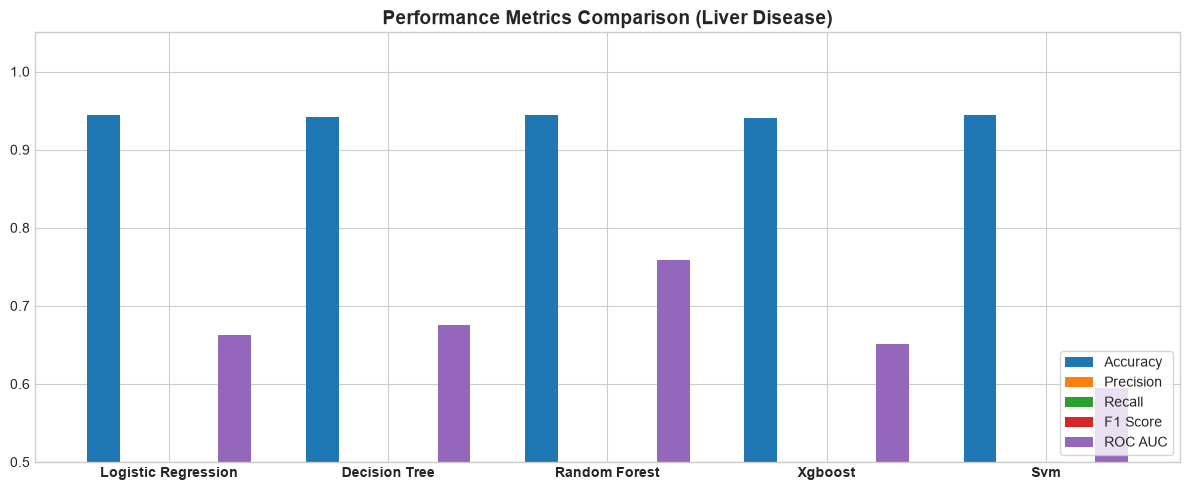

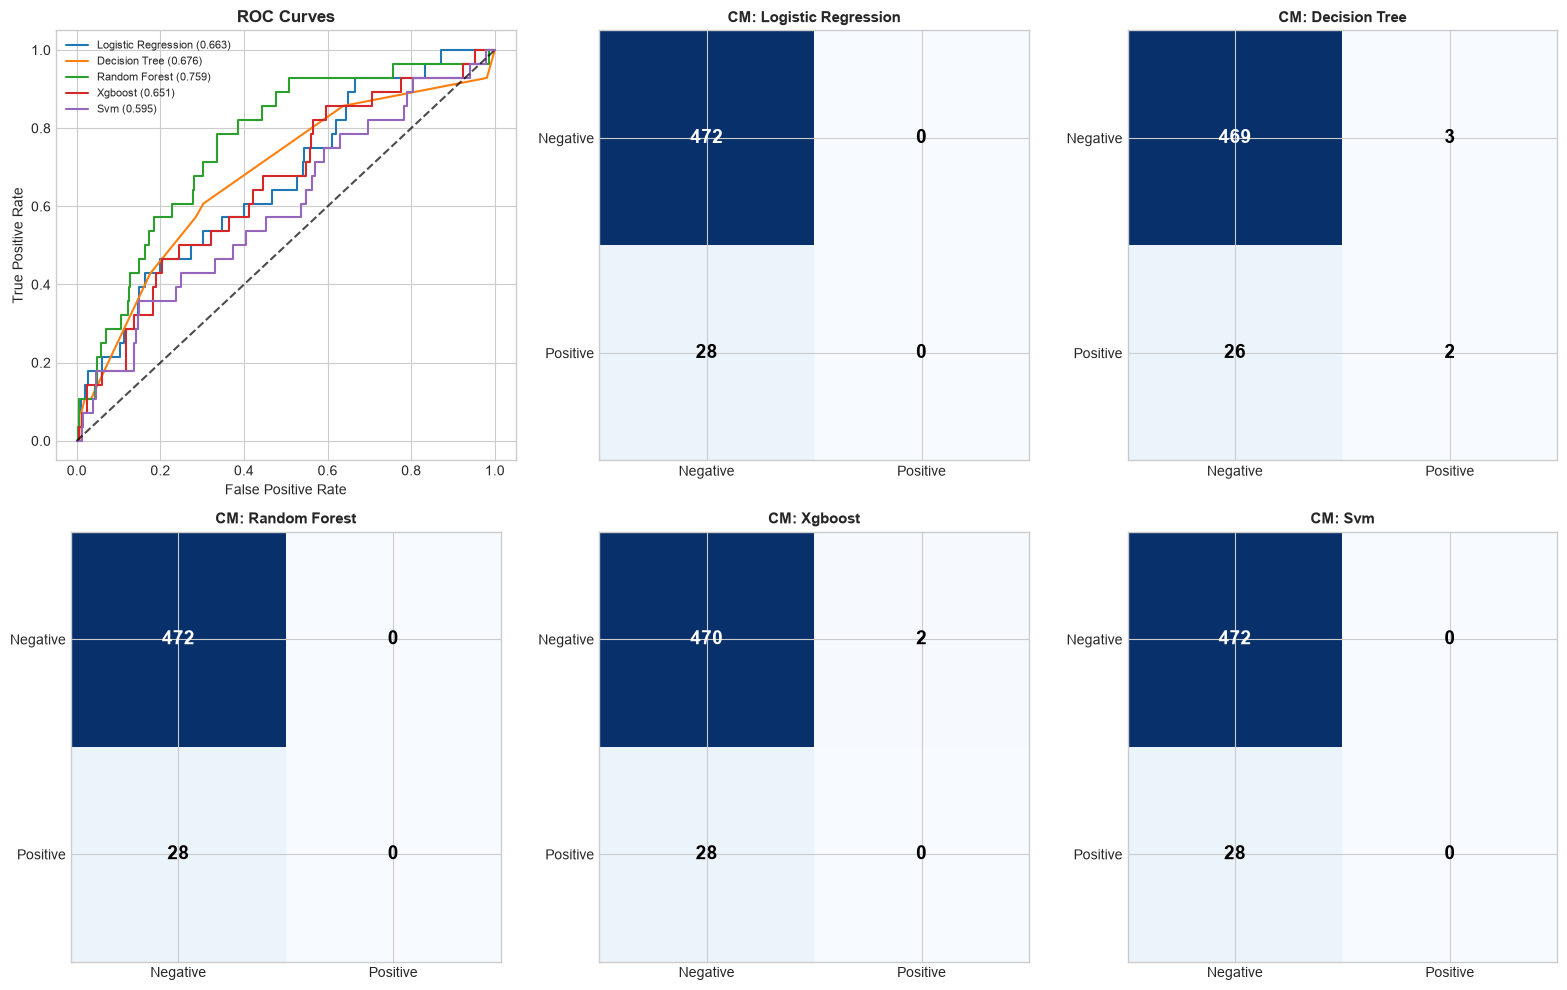

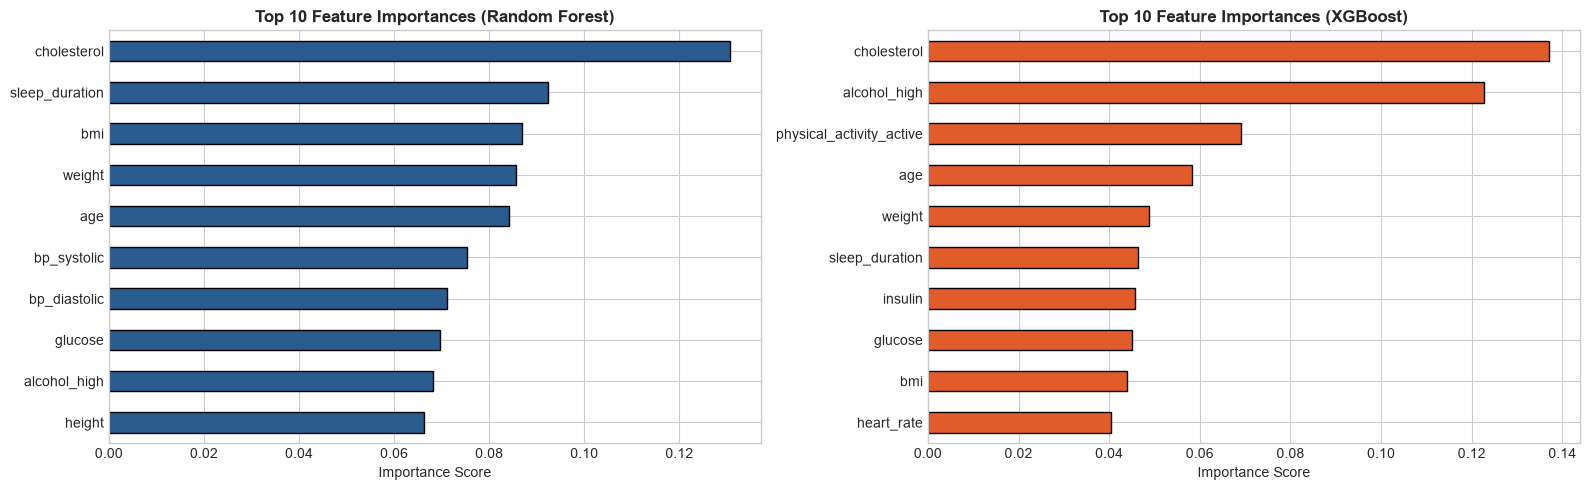

In [6]:
# Figure 1: Performance Comparison Bar Chart
fig, ax = plt.subplots(figsize=(12, 5))
alg_names_clean = [a.replace('_', ' ').title() for a in algorithms.keys()]
x = np.arange(len(alg_names_clean))
width = 0.15

acc_list = [eval_results[a]['acc'] for a in algorithms.keys()]
prec_list = [eval_results[a]['prec'] for a in algorithms.keys()]
rec_list = [eval_results[a]['rec'] for a in algorithms.keys()]
f1_list = [eval_results[a]['f1'] for a in algorithms.keys()]
auc_list = [eval_results[a]['auc'] for a in algorithms.keys()]

ax.bar(x - 2*width, acc_list, width, label='Accuracy', color='#1f77b4')
ax.bar(x - width, prec_list, width, label='Precision', color='#ff7f0e')
ax.bar(x, rec_list, width, label='Recall', color='#2ca02c')
ax.bar(x + width, f1_list, width, label='F1 Score', color='#d62728')
ax.bar(x + 2*width, auc_list, width, label='ROC AUC', color='#9467bd')

ax.set_title('Performance Metrics Comparison (Liver Disease)', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(alg_names_clean, fontsize=10, fontweight='bold')
ax.set_ylim(0.5, 1.05)
ax.legend(loc='lower right', frameon=True)
plt.tight_layout()
plt.show()

# Figure 2: ROC Curves & Confusion Matrices
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# ROC Curves (top-left plot)
ax_roc = axes[0, 0]
for alg_name in algorithms.keys():
    fpr, tpr, _ = roc_curve(y_test, eval_results[alg_name]['y_prob'])
    auc_val = eval_results[alg_name]['auc']
    ax_roc.plot(fpr, tpr, label=f"{alg_name.replace('_', ' ').title()} ({auc_val:.3f})")
ax_roc.plot([0, 1], [0, 1], 'k--', alpha=0.7)
ax_roc.set_title('ROC Curves', fontsize=12, fontweight='bold')
ax_roc.set_xlabel('False Positive Rate')
ax_roc.set_ylabel('True Positive Rate')
ax_roc.legend(fontsize=8)

# 5 Confusion Matrices
cm_positions = [(0, 1), (0, 2), (1, 0), (1, 1), (1, 2)]
for idx, (alg_name, pos) in enumerate(zip(algorithms.keys(), cm_positions)):
    ax_cm = axes[pos[0], pos[1]]
    cm = eval_results[alg_name]['cm']
    ax_cm.imshow(cm, cmap='Blues', interpolation='nearest')
    ax_cm.set_title(f"CM: {alg_name.replace('_', ' ').title()}", fontsize=11, fontweight='bold')
    ax_cm.set_xticks([0, 1])
    ax_cm.set_yticks([0, 1])
    ax_cm.set_xticklabels(['Negative', 'Positive'])
    ax_cm.set_yticklabels(['Negative', 'Positive'])
    for r in range(2):
        for c in range(2):
            ax_cm.text(c, r, str(cm[r, c]), ha='center', va='center', color='white' if cm[r, c] > cm.max()/2 else 'black', fontweight='bold', fontsize=14)

plt.tight_layout()
plt.show()

# Figure 3: Tree Feature Importances (Random Forest & XGBoost)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

rf_model = trained_models['random_forest']
xgb_model = trained_models['xgboost']

rf_importances = pd.Series(rf_model.feature_importances_, index=feature_names).sort_values(ascending=True)[-10:]
xgb_importances = pd.Series(xgb_model.feature_importances_, index=feature_names).sort_values(ascending=True)[-10:]

rf_importances.plot(kind='barh', ax=ax1, color='#2b5c8f', edgecolor='black')
ax1.set_title('Top 10 Feature Importances (Random Forest)', fontsize=12, fontweight='bold')
ax1.set_xlabel('Importance Score')

xgb_importances.plot(kind='barh', ax=ax2, color='#e05c2b', edgecolor='black')
ax2.set_title('Top 10 Feature Importances (XGBoost)', fontsize=12, fontweight='bold')
ax2.set_xlabel('Importance Score')

plt.tight_layout()
plt.show()
